In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets
diabetic_df = pd.read_csv('diab_merge_final.csv')
nondiabetic_df = pd.read_csv('nondiabetic_merged_filled.csv')

print("Diabetic dataset shape:", diabetic_df.shape)
print("Non-diabetic dataset shape:", nondiabetic_df.shape)

# Add target variable
diabetic_df['diabetic'] = 1  # Diabetic
nondiabetic_df['diabetic'] = 0  # Non-diabetic

# Check common columns between datasets
common_cols = list(set(diabetic_df.columns) & set(nondiabetic_df.columns))
print(f"Common columns: {len(common_cols)}")
print(common_cols)

Diabetic dataset shape: (68, 28)
Non-diabetic dataset shape: (378, 33)
Common columns: 28
['sleep_ord', 'father_diab_ord', 'lose_weight_ord', 'fried_food_freq_ord', 'sister_diab_ord', 'mother_diab_ord', 'BMI', 'child_diab_ord', 'veg_freq_ord', 'concern_level_ord', 'Age', 'brother_diab_ord', 'extended_diab_ord', 'activity_level_ord', 'sweetdrink_freq_ord', 'fruit_freq_ord', 'sweets_freq_ord', 'fastfood_freq_ord', 'exercise_yes_ord', 'smoking_ord', 'processed_freq_ord', 'sedentary_hours_ord', 'Weight_kg', 'Height_cm', 'diabetic', 'alcohol_ord', 'exercise_duration_ord', 'exercise_freq_ord']


In [7]:
# Select common features for both datasets
selected_features = [
    'fruit_freq_ord', 'veg_freq_ord', 'sweets_freq_ord', 
    'fastfood_freq_ord', 'processed_freq_ord', 'sweetdrink_freq_ord',
    'fried_food_freq_ord', 'lose_weight_ord', 'exercise_yes_ord',
    'exercise_freq_ord', 'exercise_duration_ord', 'sedentary_hours_ord',
    'activity_level_ord', 'sleep_ord', 'smoking_ord', 'alcohol_ord',
    'father_diab_ord', 'mother_diab_ord', 'sister_diab_ord',
    'brother_diab_ord', 'child_diab_ord', 'extended_diab_ord',
    'concern_level_ord', 'diabetic'
]

# Create unified dataset
diabetic_selected = diabetic_df[selected_features].copy()
nondiabetic_selected = nondiabetic_df[selected_features].copy()

# Combine datasets
combined_df = pd.concat([diabetic_selected, nondiabetic_selected], ignore_index=True)

print(f"Combined dataset shape: {combined_df.shape}")
print(f"Diabetic samples: {combined_df['diabetic'].sum()}")
print(f"Non-diabetic samples: {len(combined_df) - combined_df['diabetic'].sum()}")

Combined dataset shape: (446, 24)
Diabetic samples: 68
Non-diabetic samples: 378


In [8]:
# Handle missing values
def clean_data(df):
    # Fill missing values with median for numerical, mode for categorical
    numerical_cols = ['Age', 'Height_cm', 'Weight_kg', 'BMI']
    categorical_cols = [col for col in df.columns if col not in numerical_cols + ['diabetic']]
    
    for col in numerical_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col].fillna(df[col].median(), inplace=True)
    
    for col in categorical_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 0, inplace=True)
    
    return df

# Clean the data
combined_df_clean = clean_data(combined_df)

# Remove any remaining rows with missing values
combined_df_clean = combined_df_clean.dropna()

print(f"Final dataset shape after cleaning: {combined_df_clean.shape}")

Final dataset shape after cleaning: (446, 24)


C:\Users\Jarmen\AppData\Local\Temp\ipykernel_23496\2919743563.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 0, inplace=True)
C:\Users\Jarmen\AppData\Local\Temp\ipykernel_23496\2919743563.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting val

In [9]:
# Prepare features and target
feature_cols = [col for col in selected_features if col != 'diabetic']
X = combined_df_clean[feature_cols]
y = combined_df_clean['diabetic']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42),
    'SVM': SVC(random_state=42)
}

# Train and evaluate models
results = {}

for name, model in models.items():
    if name == 'Random Forest':
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"{name} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))
    print("="*50)

Random Forest Accuracy: 0.9556
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        76
           1       1.00      0.71      0.83        14

    accuracy                           0.96        90
   macro avg       0.97      0.86      0.90        90
weighted avg       0.96      0.96      0.95        90

Logistic Regression Accuracy: 0.9222
              precision    recall  f1-score   support

           0       0.95      0.96      0.95        76
           1       0.77      0.71      0.74        14

    accuracy                           0.92        90
   macro avg       0.86      0.84      0.85        90
weighted avg       0.92      0.92      0.92        90

SVM Accuracy: 0.9333
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        76
           1       0.83      0.71      0.77        14

    accuracy                           0.93        90
   macro avg       0.89      0.84      

Top 15 Most Important Features:
                  feature  importance
10  exercise_duration_ord    0.345260
22      concern_level_ord    0.082737
7         lose_weight_ord    0.069944
17        mother_diab_ord    0.059686
8        exercise_yes_ord    0.039033
5     sweetdrink_freq_ord    0.037328
18        sister_diab_ord    0.035941
3       fastfood_freq_ord    0.034021
15            alcohol_ord    0.033465
9       exercise_freq_ord    0.030309
6     fried_food_freq_ord    0.029578
4      processed_freq_ord    0.027219
16        father_diab_ord    0.022704
12     activity_level_ord    0.021871
19       brother_diab_ord    0.021645


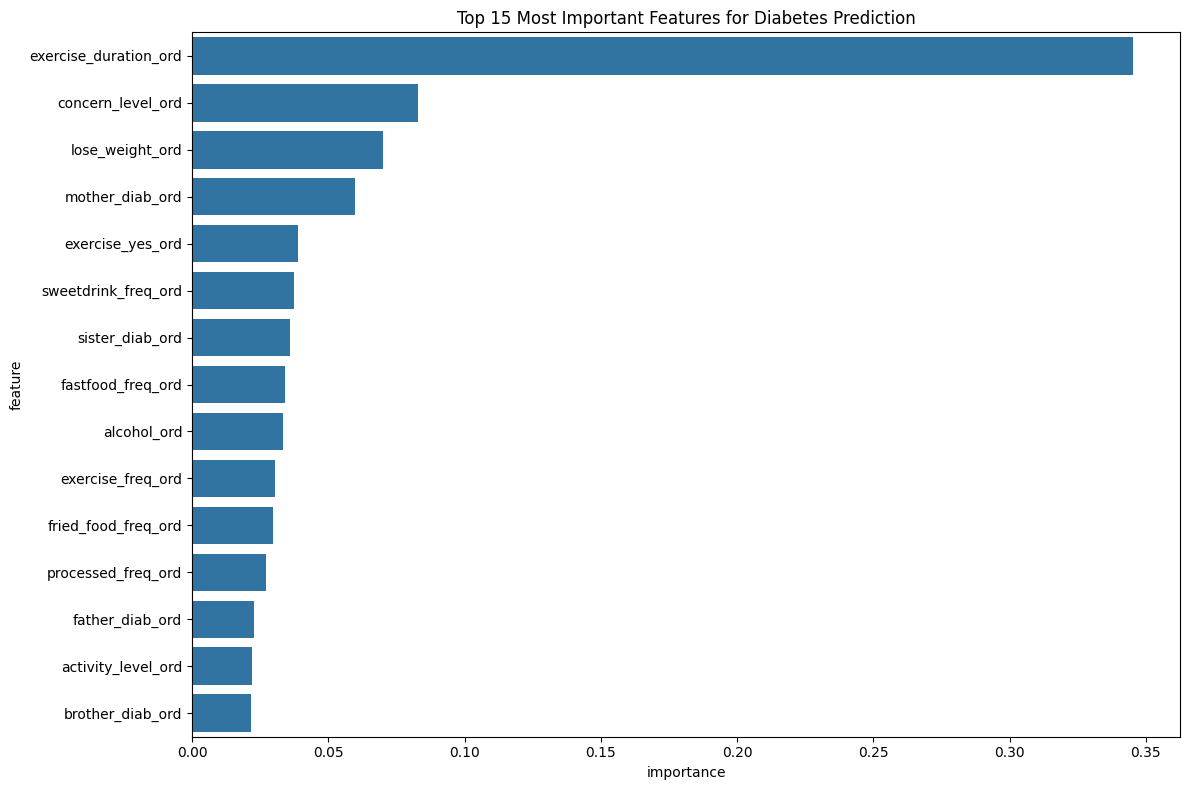

In [10]:
# Get feature importance from Random Forest
rf_model = results['Random Forest']['model']
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Most Important Features:")
print(feature_importance.head(15))

# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature')
plt.title('Top 15 Most Important Features for Diabetes Prediction')
plt.tight_layout()
plt.show()